# SPAM DETECTION

## DATA EXPLORING AND ANALYSING

### Imporation des différentes dépendances utilisées sur le projet

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Chargement de la dataset et overview

In [16]:
# chargement de notre dataset

df = pd.read_csv("spam.csv", sep=",", encoding='latin-1')

# visualisation des colones disponibles

print(df.keys())

# visualisation des 10 premières lignes

print(df.head(10))

print("\nSHAPE DE LA DATASET")
df.shape

print("\nINFO D'ENSEMBLE DE NOTRE DATASET")
df.info()

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   
5  spam  FreeMsg Hey there darling it's been 3 week's n...        NaN   
6   ham  Even my brother is not like to speak with me. ...        NaN   
7   ham  As per your request 'Melle Melle (Oru Minnamin...        NaN   
8  spam  WINNER!! As a valued network customer you have...        NaN   
9  spam  Had your mobile 11 months or more? U R entitle...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN     

### Overview des valeurs null

In [17]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

### Suppression des colones inutiles

On remarque que la dataset presente 5 colones v1, v2, et 3 autres colones non nommés. La plupart des valeurs de ces colones sont null. Étant donné qu'on a ni le nom de la colone et presque pas de données pour déduire ce à quoi ces colones servent, la moindre des choses c'est les suprimer. Nous choisisons de suprimer ces colones.


In [18]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 4', 'Unnamed: 3'])
df.keys()

Index(['v1', 'v2'], dtype='str')

### Vérification des valeurs nulls

In [19]:
df.isnull().sum()

v1    0
v2    0
dtype: int64

### Vérification des lignes dupliquées

In [20]:
print(f"Valeur dupliquées: {df.duplicated().sum()}")

Valeur dupliquées: 403


### Supression des lignes dupliquées

Il faut suprimer les lignes pour éviter les biaises du modèle

In [21]:
df = df.drop_duplicates()

# dernière vérification

print(f"Nombres de lignes dupliquées après suppression: {df.duplicated().sum()}")

Nombres de lignes dupliquées après suppression: 0


In [22]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


### Visualisation des fréquences des ham et des spam

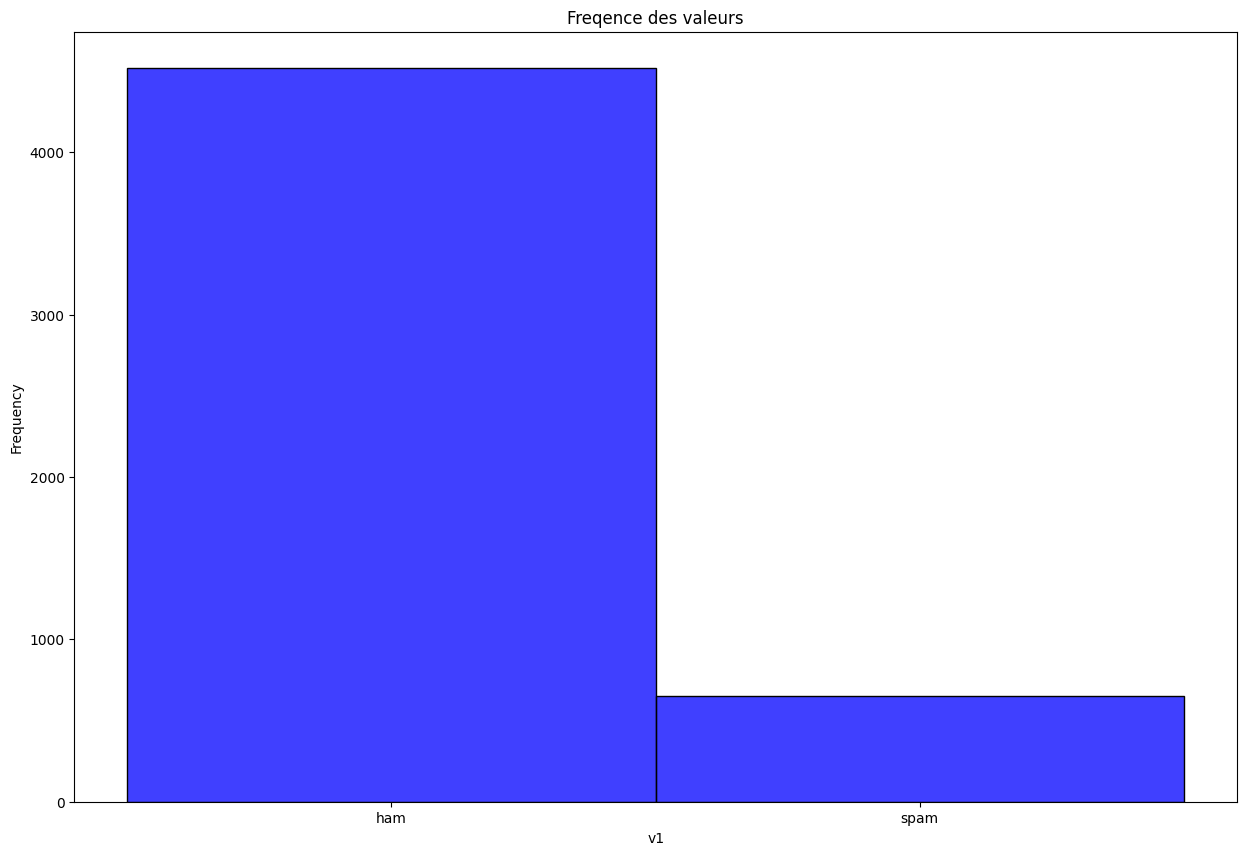

In [23]:
plt.figure(figsize=(15, 10))
sns.histplot(
    df['v1'], color="blue"
)
plt.title("Freqence des valeurs")
plt.xlabel("v1")
plt.ylabel("Frequency")
plt.show()

# Gestion du Déséquilibre des Classes (Class Imbalance)

Dans notre projet de détection de spam, on remarque beaucoup plus de messages légitimes (**Ham**) que de messages frauduleux (**Spam**). Si on ne traite pas ce problème, le modèle risque de prédire "Ham" par défaut pour obtenir un bon score, tout en laissant passer tous les spams.

### Pourquoi est-ce un problème ?
*   **Biais de l'Exactitude (Accuracy Trap) :** Si 95 % de tes données sont des "Ham", un modèle qui prédit "Ham" systématiquement aura une précision de 95 %, mais il sera totalement inutile.
*   **Mauvaise détection des minorités :** Le modèle ne voit pas assez d'exemples de spams pour apprendre leurs caractéristiques spécifiques (mots-clés, structures de phrases).

### Stratégies de Correction


| Méthode | Description | Avantages / Inconvénients |
| :--- | :--- | :--- |
| **Undersampling** | Supprimer des messages "Ham" pour égaliser les classes. |  Rapide /  Perte d'informations utiles. |
| **Oversampling** | Dupliquer des messages "Spam". | Pas de perte de données / Risque d'overfitting. |
| **SMOTE** | Créer des spams synthétiques par interpolation. | Plus robuste que le simple oversampling. |
| **Class Weights** | Donner un "poids" plus lourd aux erreurs sur le Spam. |  Simple à coder (option `class_weight='balanced'`). |

Nous choisisons d'implémenter le Undersampling pour sa rapidité et sa facilité d'implémentation

In [24]:
def undersample_scratch(df, target_column):
    # Séparer les classes
    spam_df = df[df[target_column] == 'spam']
    ham_df = df[df[target_column] == 'ham']
    
    # Déterminer la taille de la classe minoritaire
    n_spam = len(spam_df)
    
    # Tirer au sort n messages parmi les Ham
    n = int(n_spam * 1)
    ham_downsampled = ham_df.sample(n=n, random_state=42)
    
    # Combiner et mélanger
    balanced_df = pd.concat([spam_df, ham_downsampled]).sample(frac=1, random_state=42)
    return balanced_df

# Utilisation :
df_balanced = undersample_scratch(df, 'v1')


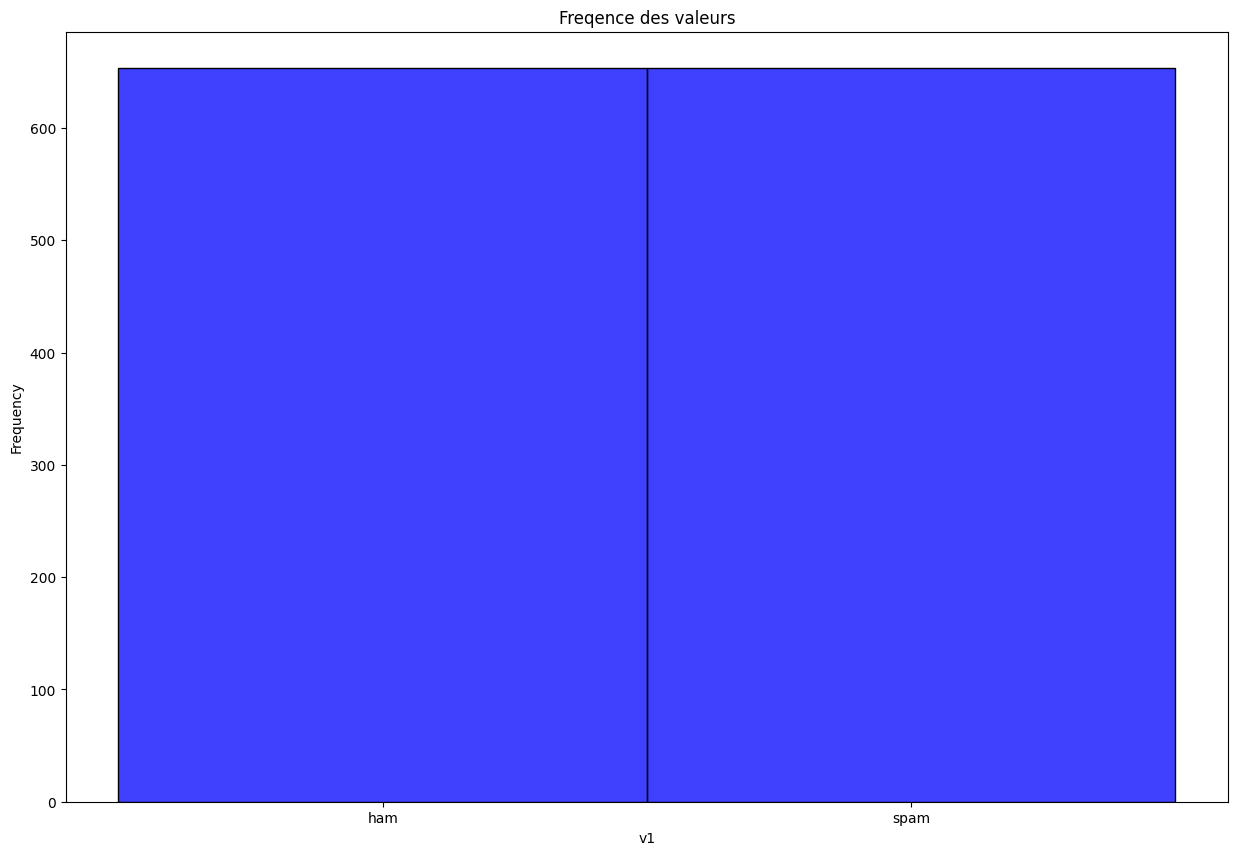

In [25]:
plt.figure(figsize=(15, 10))
sns.histplot(
    df_balanced['v1'], color="blue"
)
plt.title("Freqence des valeurs")
plt.xlabel("v1")
plt.ylabel("Frequency")
plt.show()

In [26]:
df_balanced.shape

(1306, 2)

On remarque une grande différence entre le nombre de ham et le nombre de spam.

/home/marcellin/ProjetsPersonels/epiai/Marcellin752-spam-detection/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/marcellin/ProjetsPersonels/epiai/Marcellin752-spam-detection/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/marcellin/ProjetsPersonels/epiai/Marcellin752-spam-detection/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 139 (\x8b) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


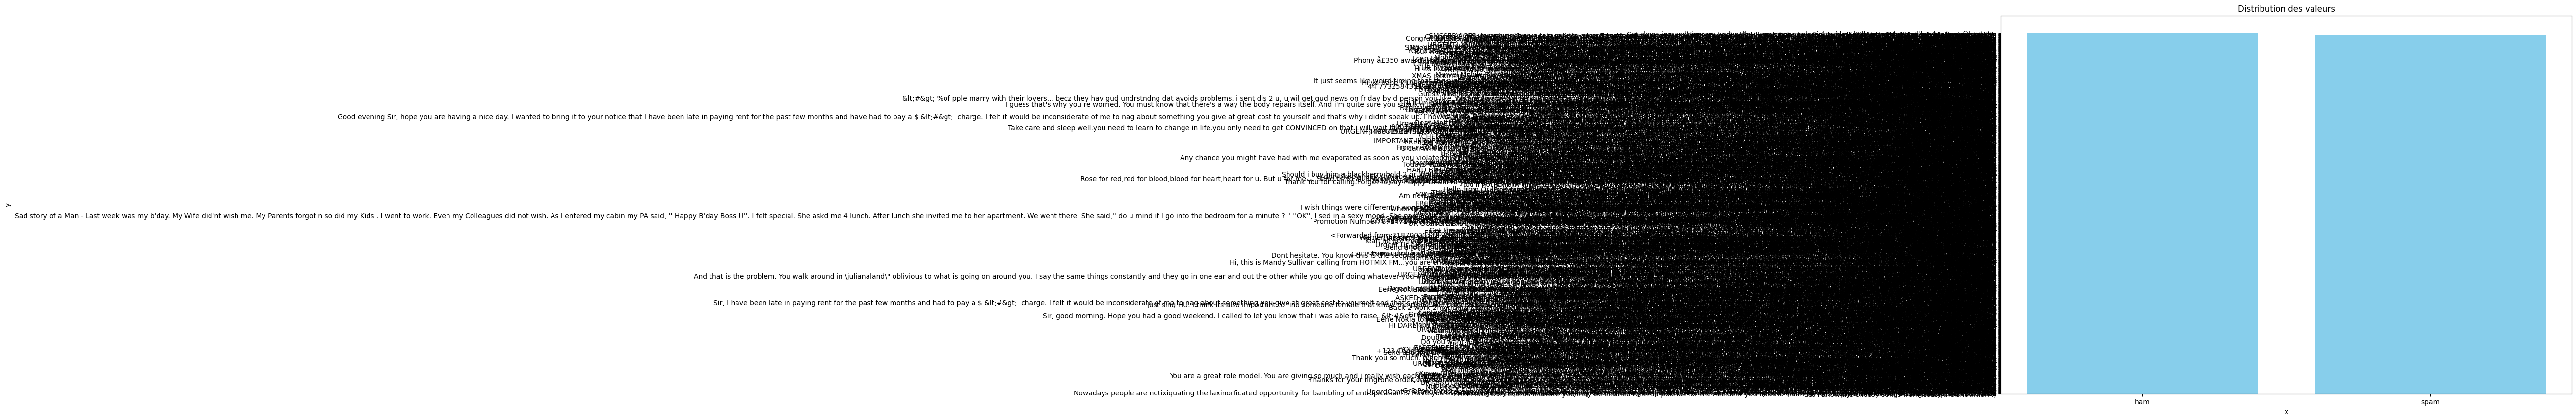

In [27]:
plt.figure(figsize=(15, 10))
plt.title("Distribution des valeurs")
plt.bar(df_balanced["v1"], df_balanced["v2"], color="skyblue")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Exportation du nouveau dataset netoyé

In [28]:
df_balanced.to_csv("cleaned_data.csv", index=False)
print("Dataset successfully saved !!!")

Dataset successfully saved !!!
